<a href="https://colab.research.google.com/github/peacewhile/PHM-Learning-Task/blob/main/NGAFID_DATASET_MINIROCKET_EXAMPLE8%E5%B8%A6%E8%BE%93%E5%87%BA%E7%BB%93%E6%9E%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!git clone https://github.com/hyang0129/NGAFIDDATASET.git

!(cd NGAFIDDATASET ; git checkout main; git reset --hard HEAD; git pull)
!(cd NGAFIDDATASET ; pip install -r requirements.txt -q)

fatal: destination path 'NGAFIDDATASET' already exists and is not an empty directory.
Already on 'main'
Your branch is up to date with 'origin/main'.
HEAD is now at fa72386 Update README.md
Already up to date.


In [9]:
!git clone https://github.com/peacewhile/PHM-Learning-Task.git
!(cd PHM-Learning-Task ; git checkout main; git reset --hard HEAD; git pull)
!(cd PHM-Learning-Task ; pip install -r requirements.txt -q)

fatal: destination path 'PHM-Learning-Task' already exists and is not an empty directory.
Already on 'main'
Your branch is up to date with 'origin/main'.
HEAD is now at 840ed16 requirements.txt
Already up to date.


In [10]:
!pip install tsai -q

In [11]:
!pip install --upgrade ipython -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.11.0 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [12]:
import sys
sys.path.append('/content/NGAFIDDATASET')

In [13]:
import sys
sys.path.append('/content/PHM-Learning-Task')

In [14]:
%load_ext autoreload

In [15]:
%autoreload
from tsai.basics import *
from tsai.models.MINIROCKET_Pytorch import *
from tsai.models.utils import *
import pandas as pd

In [16]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"随机种子已固定为 {SEED}")

随机种子已固定为 42


In [17]:
!pip install gdown -q
import gdown
import os

FILE_ID  = '14iDbAsavwNiRGm6ujNgfL2Ju9T8EcQ2Z'
DATA_DIR = '/content/2days'

if not os.path.exists(DATA_DIR):
    gdown.download(
        f'https://drive.google.com/uc?id={FILE_ID}',
        '/content/2days.tar.gz',
        quiet=False
    )
    !tar -xzf /content/2days.tar.gz -C /content/
    print("数据集下载并解压完成")
else:
    print("数据集已存在，跳过下载")

Downloading...
From (original): https://drive.google.com/uc?id=14iDbAsavwNiRGm6ujNgfL2Ju9T8EcQ2Z
From (redirected): https://drive.google.com/uc?id=14iDbAsavwNiRGm6ujNgfL2Ju9T8EcQ2Z&confirm=t&uuid=b2607d5d-816c-46fe-9935-d220b8289cab
To: /content/2days.tar.gz
100%|██████████| 1.13G/1.13G [00:21<00:00, 53.0MB/s]


数据集下载并解压完成


In [24]:
import numpy as np
import pandas as pd
import pickle

# 手动构建一个简单的 dm 对象
class SimpleDM:
    pass

dm = SimpleDM()

# 注入元数据
dm.flight_header_df = pd.read_csv(
     os.path.join(DATA_DIR, 'flight_header.csv'),
    index_col='Master Index'
)

# 注入时序数据
with open(os.path.join(DATA_DIR, 'flight_data.pkl'), 'rb') as f:
    dm.data_dict = pickle.load(f)

# 加载归一化参数
stats = pd.read_csv(os.path.join(DATA_DIR, 'stats.csv'), index_col=0)
print(stats.head())
print(stats.shape)

   volt1  volt2   amp1  amp2  FQtyL  FQtyR  E1 FFlow  E1 OilT  E1 OilP  \
0   31.5   31.7   98.8  18.0   54.0   54.0    227.65    404.5   162.24   
1    0.0    0.0 -157.4  -5.6    0.0    0.0      0.00    -58.0   -14.55   

   E1 RPM  ...  E1 EGT2  E1 EGT3  E1 EGT4   OAT     IAS      VSpd  NormAc  \
0  3248.0  ...  1973.37  2003.87  2094.29  47.2  454.97  14160.48    2.92   
1     0.0  ...  -321.61  -336.31  -333.87 -57.2  -10.64 -32747.37   -2.41   

    AltMSL  timestep  cluster  
0  14744.4     30058      c_9  
1  -4324.1         0      c_1  

[2 rows x 25 columns]
(2, 25)


In [26]:
import numpy as np
stats_numeric = stats.drop(columns=['cluster'])
dm.mins = stats_numeric.loc[1].values.astype(np.float32)
dm.maxs = stats_numeric.loc[0].values.astype(np.float32)

In [27]:
import types

def get_numpy_dataset(self, fold, training):
    if training:
        mask = self.flight_header_df['fold'] != fold
    else:
        mask = self.flight_header_df['fold'] == fold
    subset = self.flight_header_df[mask]
    data = [self.data_dict[idx] for idx in subset.index]
    return {
        'data':         data,
        'target_class': subset['target_class'].values,
        'before_after': subset['before_after'].values,
        'fold':         subset['fold'].values
    }

dm.get_numpy_dataset = types.MethodType(get_numpy_dataset, dm)

In [28]:
from fastai.callback.progress import CSVLogger

from tqdm.autonotebook import tqdm

In [29]:
def pad_or_truncate(data_list, target_len=3000):
    result = []
    for arr in data_list:
        T = arr.shape[0]
        if T >= target_len:
            arr = arr[:target_len, :]
        else:
            pad = np.zeros((target_len - T, arr.shape[1]), dtype=np.float32)
            arr = np.concatenate([arr, pad], axis=0)
        result.append(arr)
    return np.array(result, dtype=np.float32).transpose(0, 2, 1)

  0%|          | 0/5 [00:00<?, ?it/s]

epoch,train_loss,valid_loss,accuracy,time
0,0.689068,0.688266,0.542795,00:04
1,0.685926,0.686410,0.554585,00:04
2,0.683757,0.685340,0.557205,00:04
3,0.683227,0.683911,0.553712,00:03
4,0.681000,0.682954,0.561135,00:04
5,0.680623,0.682766,0.565502,00:04
6,0.678450,0.681835,0.567686,00:04
7,0.677409,0.682673,0.558079,00:04
8,0.676278,0.680875,0.565066,00:04
9,0.673113,0.680028,0.569869,00:04


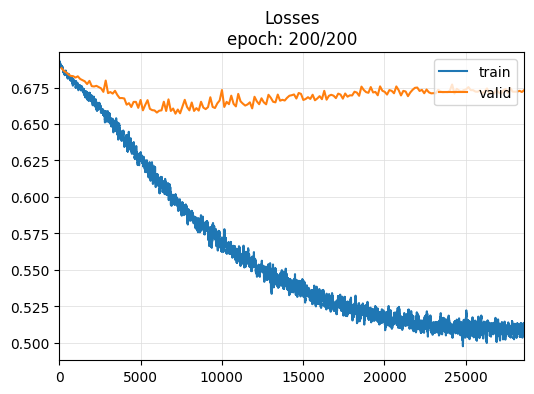

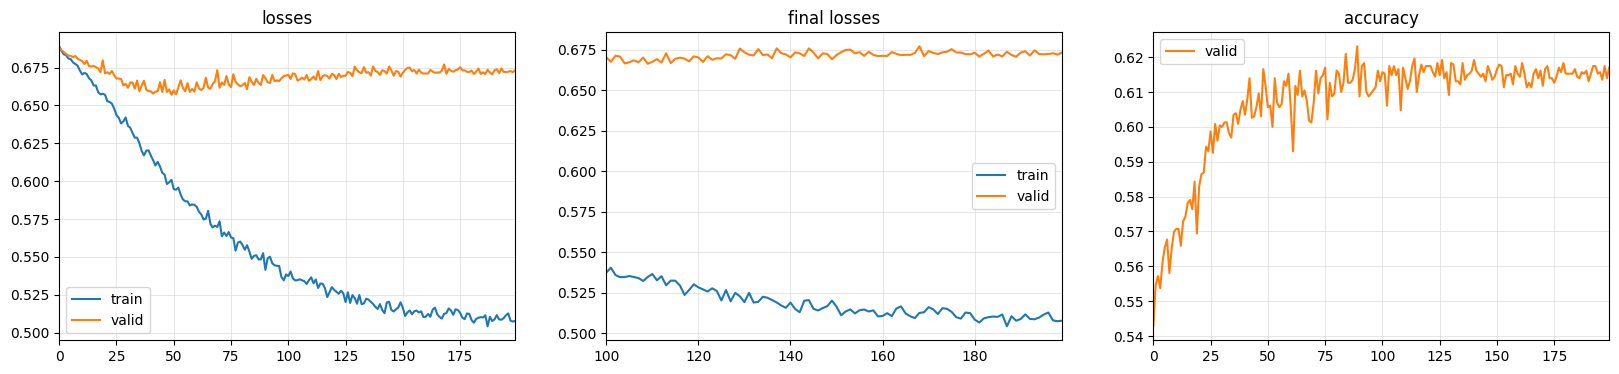

Fold 0 → Accuracy: 0.6170  F1: 0.6051  ROC-AUC: 0.6538


epoch,train_loss,valid_loss,accuracy,time
0,0.689111,0.688725,0.538663,00:07
1,0.686578,0.686838,0.556575,00:04
2,0.683604,0.685361,0.553517,00:04
3,0.681689,0.684559,0.557449,00:04
4,0.680707,0.683343,0.557012,00:04
5,0.679455,0.682529,0.557449,00:04
6,0.675360,0.681470,0.567060,00:04
7,0.677452,0.680746,0.563565,00:04
8,0.677141,0.680436,0.570118,00:05
9,0.672716,0.680118,0.572739,00:04


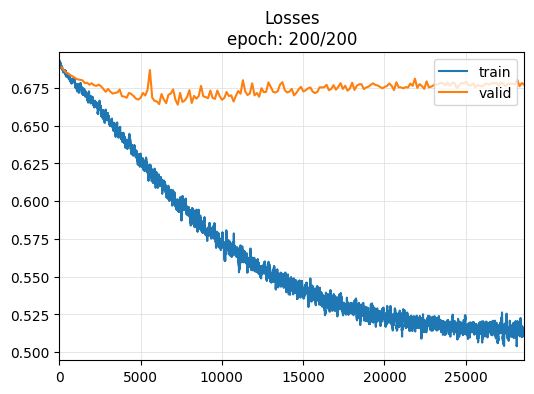

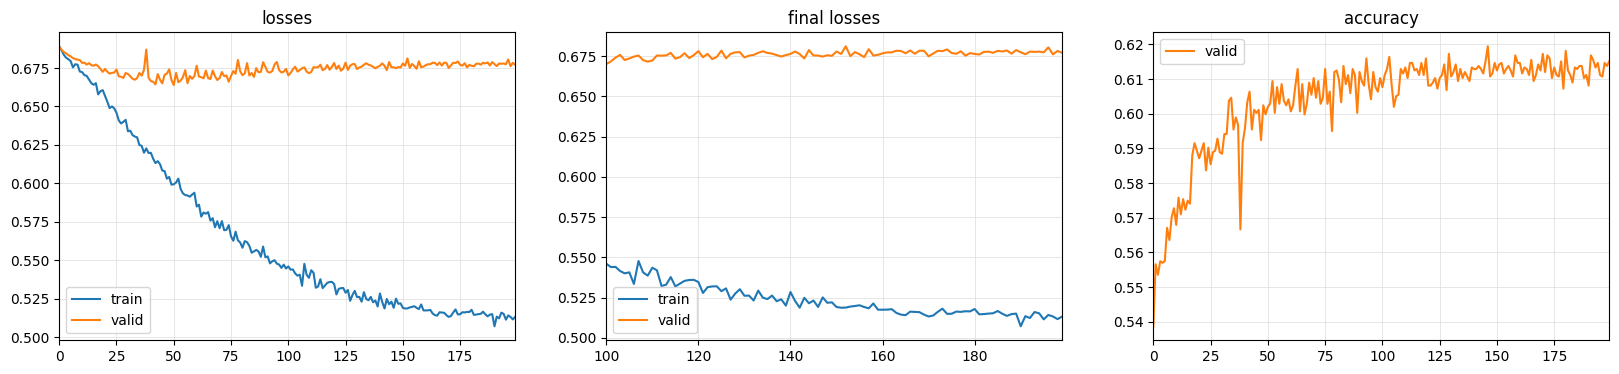

Fold 1 → Accuracy: 0.6151  F1: 0.6114  ROC-AUC: 0.6485


epoch,train_loss,valid_loss,accuracy,time
0,0.690929,0.686843,0.557012,00:04
1,0.687385,0.684745,0.560944,00:04
2,0.685215,0.683023,0.563565,00:04
3,0.684247,0.681915,0.567060,00:04
4,0.683442,0.680577,0.564439,00:04
5,0.681218,0.679751,0.574924,00:04
6,0.679376,0.678543,0.575797,00:04
7,0.678869,0.677231,0.564002,00:04
8,0.676820,0.676672,0.570555,00:04
9,0.673606,0.674483,0.567497,00:04


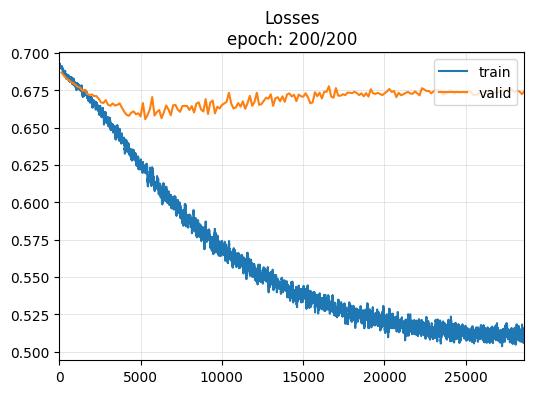

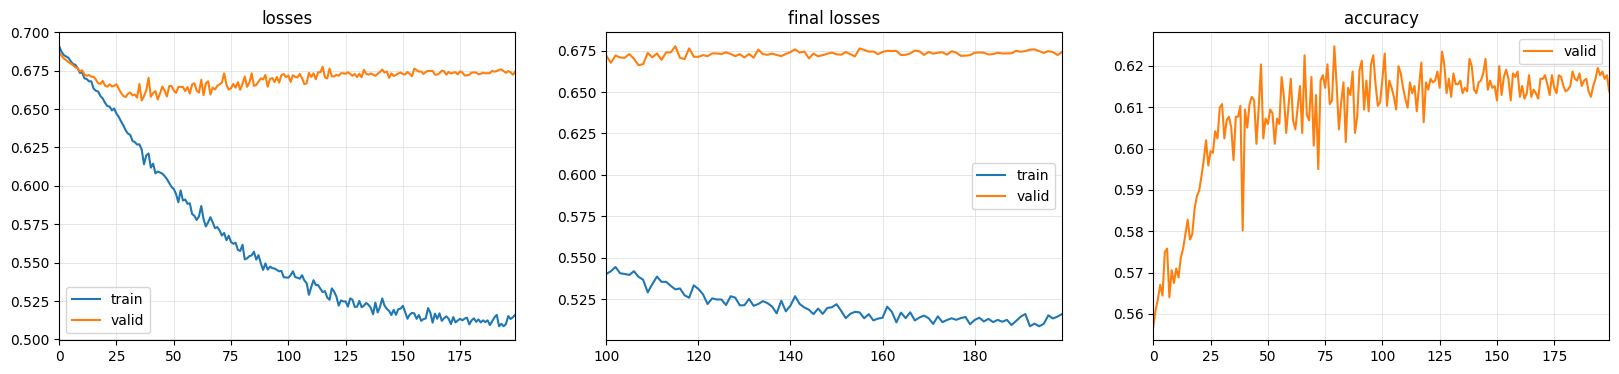

Fold 2 → Accuracy: 0.6138  F1: 0.5974  ROC-AUC: 0.6490


epoch,train_loss,valid_loss,accuracy,time
0,0.689994,0.688620,0.543032,00:04
1,0.687462,0.686625,0.553517,00:04
2,0.683918,0.685372,0.554391,00:04
3,0.682079,0.683570,0.557449,00:04
4,0.681386,0.681877,0.564439,00:04
5,0.680558,0.680990,0.570992,00:04
6,0.677786,0.680473,0.569681,00:04
7,0.678230,0.678465,0.569681,00:04
8,0.677020,0.677503,0.574050,00:04
9,0.676441,0.676286,0.580603,00:05


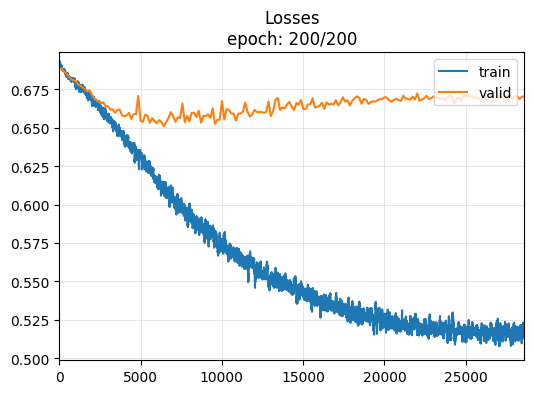

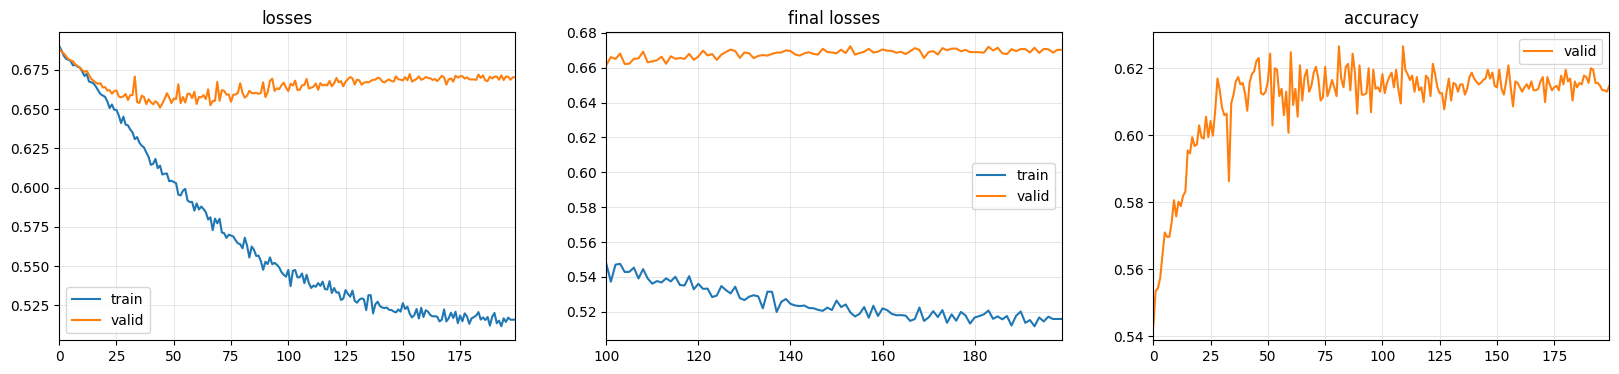

Fold 3 → Accuracy: 0.6147  F1: 0.5905  ROC-AUC: 0.6557


epoch,train_loss,valid_loss,accuracy,time
0,0.689031,0.689225,0.538663,00:04
1,0.687339,0.687512,0.536916,00:04
2,0.686161,0.686042,0.545216,00:04
3,0.683576,0.684801,0.550022,00:04
4,0.680066,0.683734,0.551332,00:04
5,0.680437,0.682961,0.563128,00:04
6,0.678982,0.682313,0.555701,00:04
7,0.676768,0.680914,0.564875,00:04
8,0.675605,0.679742,0.571865,00:04
9,0.676359,0.679117,0.573613,00:04


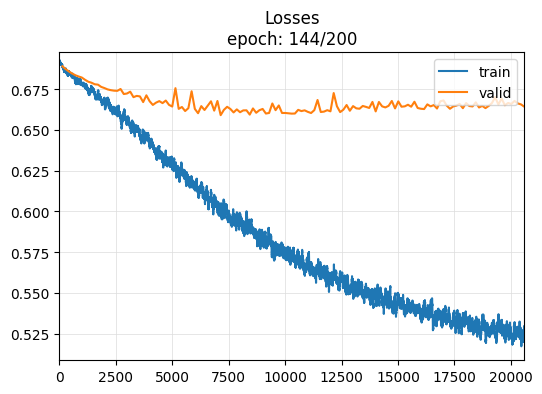

epoch,train_loss,valid_loss,accuracy,time
0,0.689031,0.689225,0.538663,00:04
1,0.687339,0.687512,0.536916,00:04
2,0.686161,0.686042,0.545216,00:04
3,0.683576,0.684801,0.550022,00:04
4,0.680066,0.683734,0.551332,00:04
5,0.680437,0.682961,0.563128,00:04
6,0.678982,0.682313,0.555701,00:04
7,0.676768,0.680914,0.564875,00:04
8,0.675605,0.679742,0.571865,00:04
9,0.676359,0.679117,0.573613,00:04


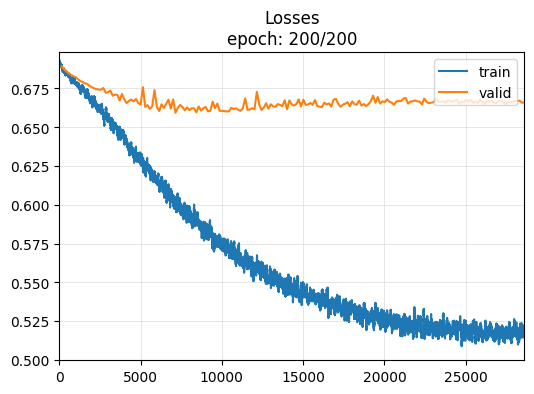

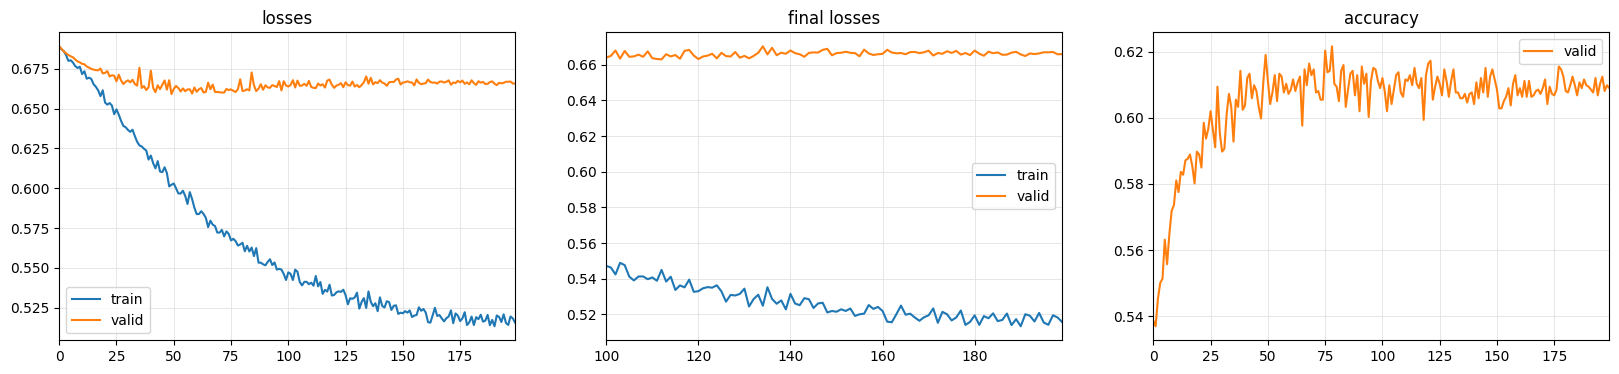

Fold 4 → Accuracy: 0.6090  F1: 0.5915  ROC-AUC: 0.6551

========== 五折交叉验证结果 ==========
Fold     Accuracy     F1           ROC-AUC     
--------------------------------------------
Fold 0    0.6170       0.6051       0.6538      
Fold 1    0.6151       0.6114       0.6485      
Fold 2    0.6138       0.5974       0.6490      
Fold 3    0.6147       0.5905       0.6557      
Fold 4    0.6090       0.5915       0.6551      
--------------------------------------------
均值       0.6139       0.5992       0.6524      
标准差      0.0027        0.0080        0.0030      


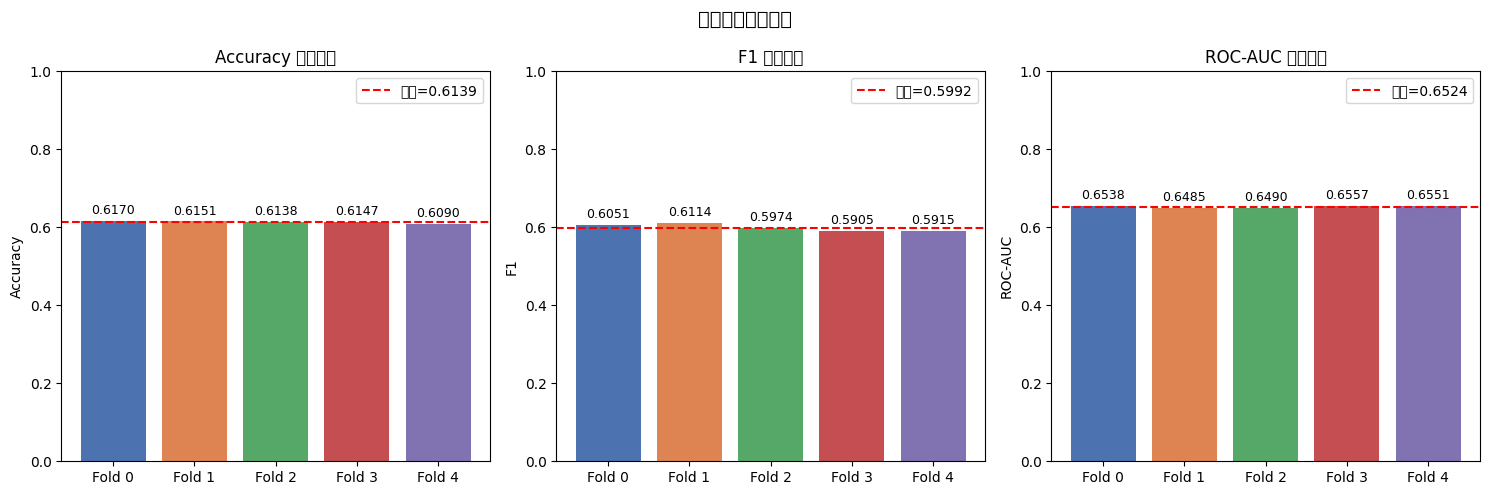

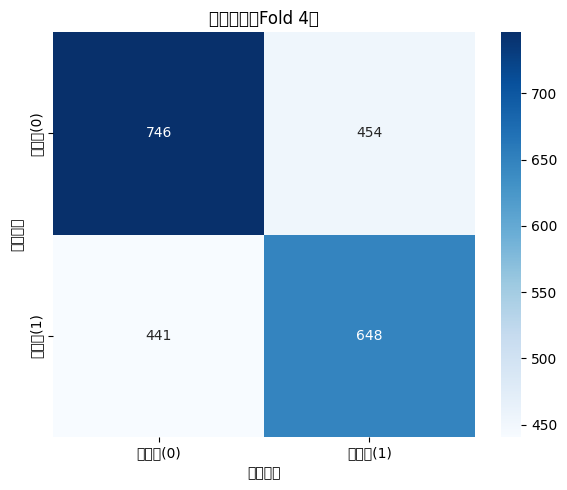

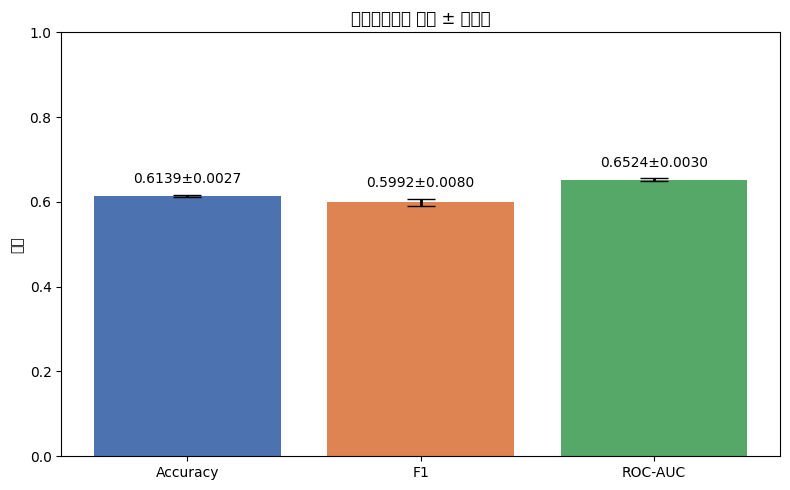

In [31]:
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

save_path = '.'
model_name = 'MINIROCKET_BINARY'

mins23 = dm.mins[:23].reshape(-1, 1)
maxs23 = dm.maxs[:23].reshape(-1, 1)

# 收集每折指标
fold_accuracies = []
fold_f1s = []
fold_aucs = []

# 收集最后一折预测结果（用于混淆矩阵）
last_fold_pred_labels = None
last_fold_test_Y = None

for fold in tqdm(range(5)):

    save_filename = save_path + '%s_%i' % (model_name, fold)

    train_dict = dm.get_numpy_dataset(fold=fold, training=True)
    test_dict  = dm.get_numpy_dataset(fold=fold, training=False)

    train_X = pad_or_truncate(train_dict['data'], target_len=200)
    train_X = (train_X - mins23) / (maxs23 - mins23)
    train_X = np.nan_to_num(train_X, copy=False)

    test_X = pad_or_truncate(test_dict['data'], target_len=200)
    test_X = (test_X - mins23) / (maxs23 - mins23)
    test_X = np.nan_to_num(test_X, copy=False)

    train_Y = np.array(train_dict['before_after'])
    test_Y  = np.array(test_dict['before_after'])

    splits = [list(np.arange(len(train_Y)))]
    splits.append(list(np.arange(len(test_Y)) + len(train_Y)))

    torch.cuda.empty_cache()
    mrf = MiniRocketFeatures(train_X.shape[1], train_X.shape[2]).to(default_device())
    chunksize = 32

    mrf.fit(train_X, chunksize=chunksize)

    X_feat = get_minirocket_features(np.concatenate([train_X, test_X]), mrf, chunksize=chunksize, to_np=True)

    Y = np.concatenate([train_Y, test_Y])

    PATH = Path("./models/MRF.pt")
    PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(mrf.state_dict(), PATH)

    tfms = [None, TSClassification()]
    batch_tfms = TSStandardize(by_sample=True)
    dls = get_ts_dls(X_feat, Y, splits=splits, tfms=tfms, batch_tfms=batch_tfms)
    model = build_ts_model(MiniRocketHead, dls=dls)

    learn = Learner(dls, model, metrics=accuracy, cbs=[ShowGraph(), CSVLogger(save_filename)])

    results = learn.fit_one_cycle(200, 2.5e-5)

    # 获取测试集预测结果
    preds, targets = learn.get_preds(ds_idx=1)
    pred_probs  = preds[:, 1].numpy()
    pred_labels = preds.argmax(dim=1).numpy()

    # 计算三个指标
    acc = (pred_labels == test_Y).mean()
    f1  = f1_score(test_Y, pred_labels, average='binary')
    auc = roc_auc_score(test_Y, pred_probs)

    fold_accuracies.append(acc)
    fold_f1s.append(f1)
    fold_aucs.append(auc)

    print(f"Fold {fold} → Accuracy: {acc:.4f}  F1: {f1:.4f}  ROC-AUC: {auc:.4f}")

    # 保存最后一折预测结果
    if fold == 4:
        last_fold_pred_labels = pred_labels
        last_fold_test_Y      = test_Y

    # 每折结束后释放内存
    del train_X, test_X, X_feat, mrf, model, learn, dls, results
    torch.cuda.empty_cache()
    gc.collect()

# ========== 汇总报告 ==========
fold_accuracies = np.array(fold_accuracies)
fold_f1s        = np.array(fold_f1s)
fold_aucs       = np.array(fold_aucs)

print("\n========== 五折交叉验证结果 ==========")
print(f"{'Fold':<8} {'Accuracy':<12} {'F1':<12} {'ROC-AUC':<12}")
print("-" * 44)
for i in range(5):
    print(f"Fold {i:<4} {fold_accuracies[i]:<12.4f} {fold_f1s[i]:<12.4f} {fold_aucs[i]:<12.4f}")
print("-" * 44)
print(f"{'均值':<8} {fold_accuracies.mean():<12.4f} {fold_f1s.mean():<12.4f} {fold_aucs.mean():<12.4f}")
print(f"{'标准差':<8} {fold_accuracies.std():<12.4f}  {fold_f1s.std():<12.4f}  {fold_aucs.std():<12.4f}")
print("======================================")

# ========== 图1：五折指标柱状图 ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
folds = [f'Fold {i}' for i in range(5)]
metrics = {
    'Accuracy': fold_accuracies,
    'F1':       fold_f1s,
    'ROC-AUC':  fold_aucs
}

for ax, (name, values) in zip(axes, metrics.items()):
    bars = ax.bar(folds, values,
                  color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
    ax.axhline(y=values.mean(), color='red', linestyle='--',
               label=f'均值={values.mean():.4f}')
    ax.set_title(f'{name} 各折结果')
    ax.set_ylabel(name)
    ax.set_ylim(0, 1)
    ax.legend()
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('五折交叉验证结果', fontsize=14)
plt.tight_layout()
plt.savefig('fold_metrics.png', dpi=150)
plt.show()

# ========== 图2：混淆矩阵（最后一折）==========
cm = confusion_matrix(last_fold_test_Y, last_fold_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['维护后(0)', '维护前(1)'],
            yticklabels=['维护后(0)', '维护前(1)'])
plt.title('混淆矩阵（Fold 4）')
plt.ylabel('真实标签')
plt.xlabel('预测标签')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ========== 图3：均值±标准差汇总图 ==========
fig, ax = plt.subplots(figsize=(8, 5))
metric_names = ['Accuracy', 'F1', 'ROC-AUC']
means = [fold_accuracies.mean(), fold_f1s.mean(), fold_aucs.mean()]
stds  = [fold_accuracies.std(),  fold_f1s.std(),  fold_aucs.std()]

bars = ax.bar(metric_names, means, yerr=stds, capsize=10,
              color=['#4C72B0', '#DD8452', '#55A868'],
              error_kw={'elinewidth': 2, 'ecolor': 'black'})
ax.set_ylim(0, 1)
ax.set_title('五折交叉验证 均值 ± 标准差')
ax.set_ylabel('分数')

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.02,
            f'{mean:.4f}±{std:.4f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('metrics_summary.png', dpi=150)
plt.show()
